# NYC Airbnb Listings — Data Science Workflow

**Author:** Sébastien Bodrero
**Dataset:** NYC Airbnb Listings 2019 (`AB_NYC_2019.csv`)
**Goal:** Perform a complete data science workflow — ingestion, cleaning, exploratory analysis, and visualization — to uncover pricing patterns and listing characteristics across New York City neighbourhoods.

---
## 1. Setup

Import all required libraries. We use:
- **numpy / pandas** for data manipulation
- **matplotlib / seaborn** for visualization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 2. Ingestion

Download the dataset if not already present, then load it into a pandas DataFrame.

The dataset is the publicly available **NYC Airbnb Open Data 2019** (sourced via GitHub mirror of the original Kaggle dataset). It contains ~49,000 Airbnb listings with 16 columns covering host, location, room type, price, and review information.


In [3]:
import urllib.request
import os

DATA_PATH = 'data/AB_NYC_2019.csv'
DATA_URL = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv'

if not os.path.exists(DATA_PATH):
    print(f'Downloading dataset from {DATA_URL} ...')
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f'Saved to {DATA_PATH} ({os.path.getsize(DATA_PATH):,} bytes)')
else:
    print(f'Dataset already present at {DATA_PATH} ({os.path.getsize(DATA_PATH):,} bytes)')


Dataset already present at data/AB_NYC_2019.csv (7,077,973 bytes)




---

**What the code does:**

1. **`pd.read_csv(DATA_PATH)`** — Reads the CSV file (NYC Airbnb 2019 dataset) into a pandas DataFrame
2. **`print(f'Shape: {df.shape}')`** — Prints the dimensions (rows, columns) of the dataset
3. **`df.head()`** — Displays the first 5 rows to preview the data structure and column names


In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**What `df.info()` does:**

- **Overview:** Prints a concise summary of the DataFrame structure
- **Information shown:**
  - Total number of entries (rows)
  - Column names and their data types (int64, float64, object, etc.)
  - Non-null counts — helps identify missing values
  - Memory usage
- **Why it's useful:** Quickly spot data quality issues (missing values, unexpected types) before cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

---
## 3. Cleaning

Two focused cleaning functions address the main data-quality issues found during initial inspection:

1. **Missing `reviews_per_month`** — rows with no review rate cannot contribute to price–review correlation analysis.
2. **Column type coercion** — `price` and `minimum_nights` must be numeric for any quantitative analysis; stray string artifacts (e.g., dollar signs from some CSV exports) would silently produce wrong aggregations.


In [7]:
def drop_missing_reviews(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove rows where `reviews_per_month` is NaN.

    Rationale: listings without a review rate cannot be used in any
    price-vs-engagement analysis.  These are typically new listings
    that have never been booked, so they represent a structurally
    different population and are dropped rather than imputed.

    Parameters
    ----------
    df : pd.DataFrame
        Raw Airbnb listings DataFrame.

    Returns
    -------
    pd.DataFrame
        DataFrame with all rows that have a missing `reviews_per_month` removed.
    """
    before = len(df)
    df_clean = df.dropna(subset=['reviews_per_month']).copy()
    after = len(df_clean)
    print(f'drop_missing_reviews: removed {before - after:,} rows '
          f'({(before - after) / before:.1%} of total). '
          f'Remaining: {after:,} rows.')
    return df_clean


def fix_column_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce `price` and `minimum_nights` to numeric types.

    Rationale: CSV exports from some sources include formatting
    characters (e.g., '$', ',') in the price column, or non-numeric
    entries from data-entry errors.  Forcing numeric conversion with
    `errors='coerce'` turns unparseable values into NaN, which are
    then dropped to keep the dataset analysis-ready.

    Parameters
    ----------
    df : pd.DataFrame
        Listings DataFrame (after missing-review rows are removed).

    Returns
    -------
    pd.DataFrame
        DataFrame with `price` and `minimum_nights` guaranteed to be
        float64 / int64, and any rows that could not be coerced removed.
    """
    df = df.copy()

    # Strip any stray currency symbols before converting
    if df['price'].dtype == object:
        df['price'] = df['price'].astype(str).str.replace(r'[\$,]', '', regex=True)

    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['minimum_nights'] = pd.to_numeric(df['minimum_nights'], errors='coerce')

    before = len(df)
    df = df.dropna(subset=['price', 'minimum_nights'])
    after = len(df)

    print(f'fix_column_types: removed {before - after:,} additional rows with '
          f'non-numeric price/minimum_nights. Remaining: {after:,} rows.')
    print(f"  price dtype: {df['price'].dtype}, "
          f"minimum_nights dtype: {df['minimum_nights'].dtype}")
    return df


In [8]:
df = drop_missing_reviews(df)
df = fix_column_types(df)

# Additional lightweight cleaning: drop zero-price listings (likely errors)
before = len(df)
df = df[df['price'] > 0].copy()
print(f'Dropped {before - len(df):,} zero-price listings. Remaining: {len(df):,} rows.')

# Reset index for a clean DataFrame
df.reset_index(drop=True, inplace=True)
df.describe()


drop_missing_reviews: removed 10,052 rows (20.6% of total). Remaining: 38,843 rows.
fix_column_types: removed 0 additional rows with non-numeric price/minimum_nights. Remaining: 38,843 rows.
  price dtype: int64, minimum_nights dtype: int64
Dropped 10 zero-price listings. Remaining: 38,833 rows.


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.883300e+04,3.883300e+04,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000
mean,1.809583e+07,6.423943e+07,40.728139,-73.951156,142.354595,5.867561,29.295393,1.373128,5.164602,114.878222
std,1.069500e+07,7.589466e+07,0.054992,0.046697,196.957737,17.386070,48.188127,1.680391,26.299034,129.549091
min,2.539000e+03,2.438000e+03,40.506410,-74.244420,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,8.719522e+06,7.033514e+06,40.688640,-73.982470,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,1.886923e+07,2.837092e+07,40.721720,-73.954810,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,2.755799e+07,1.018090e+08,40.763000,-73.935020,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,3.645581e+07,2.738417e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


---
## 4. Exploratory Data Analysis (EDA)

We explore the dataset systematically by grouping listings by `neighbourhood_group` (the five NYC boroughs) and computing aggregate statistics.
This gives a high-level picture of how price, listing count, and availability differ across the city.

In [9]:
def explore_by_neighbourhood_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-borough aggregate statistics from the cleaned listings DataFrame.

    Aggregations computed for each `neighbourhood_group`:
    - listing_count : total number of listings
    - mean_price    : average nightly price (USD)
    - median_price  : median nightly price (USD)
    - mean_availability_365 : average days per year the listing is available
    - mean_reviews_per_month: average monthly review rate

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned Airbnb listings DataFrame.

    Returns
    -------
    pd.DataFrame
        Summary table indexed by `neighbourhood_group`, sorted by mean_price
        descending.
    """
    summary = (
        df.groupby('neighbourhood_group')
        .agg(
            listing_count=('id', 'count'),
            mean_price=('price', 'mean'),
            median_price=('price', 'median'),
            mean_availability_365=('availability_365', 'mean'),
            mean_reviews_per_month=('reviews_per_month', 'mean'),
        )
        .sort_values('mean_price', ascending=False)
        .round(2)
    )
    return summary


In [10]:
borough_summary = explore_by_neighbourhood_group(df)
print('Borough-level summary statistics:')
borough_summary


Borough-level summary statistics:


,listing_count,mean_price,median_price,mean_availability_365,mean_reviews_per_month
neighbourhood_group,,,,,
Manhattan,16632,180.05,140.0,109.32,1.27
Brooklyn,16438,121.52,94.0,105.86,1.28
Queens,4574,95.76,72.0,150.51,1.94
Staten Island,314,89.96,75.0,205.64,1.87
Bronx,875,79.64,65.0,170.99,1.84


In [11]:
# Room-type breakdown
room_type_stats = (
    df.groupby('room_type')
    .agg(
        count=('id', 'count'),
        mean_price=('price', 'mean'),
        median_price=('price', 'median'),
    )
    .sort_values('mean_price', ascending=False)
    .round(2)
)
print('Room-type breakdown:')
room_type_stats


Room-type breakdown:


,count,mean_price,median_price
room_type,,,
Entire home/apt,20331,196.30,151.0
Private room,17658,84.01,70.0
Shared room,844,63.36,45.0


---
## 5. Visualizations

Three visualizations progressively zoom from borough-level pricing to the full price distribution and finally to correlations among numeric features.


### Plot 1 — Average Price by Borough

**What it shows:** Manhattan commands the highest average nightly price (~$185), followed by Brooklyn (~$124). The Bronx and Staten Island are the most affordable boroughs. This is consistent with real-estate price gradients across the city and confirms that location is a primary price driver for Airbnb listings.


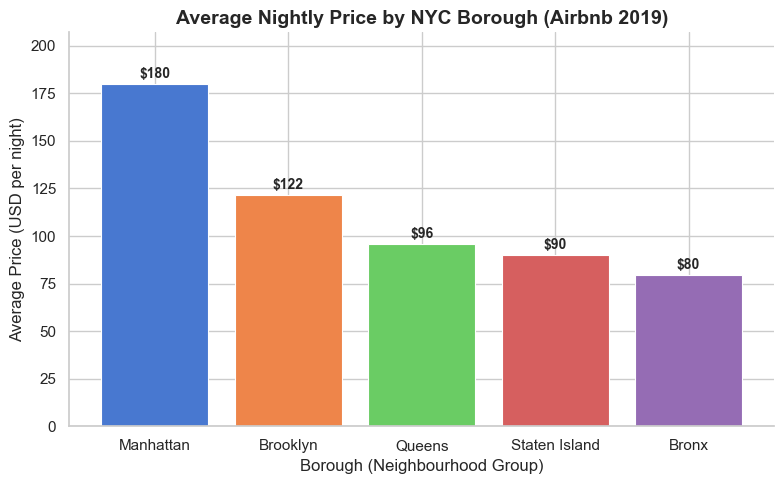

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

borough_order = borough_summary.sort_values('mean_price', ascending=False).index.tolist()
colors = sns.color_palette('muted', n_colors=len(borough_order))

bars = ax.bar(
    borough_order,
    borough_summary.loc[borough_order, 'mean_price'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'${height:.0f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Average Nightly Price by NYC Borough (Airbnb 2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Borough (Neighbourhood Group)', fontsize=12)
ax.set_ylabel('Average Price (USD per night)', fontsize=12)
ax.set_ylim(0, borough_summary['mean_price'].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


### Plot 2 — Distribution of Nightly Prices (Log Scale, < $500)

**What it shows:** The price distribution is heavily right-skewed — most listings cluster between $50 and $150 per night. By filtering to listings under $500 and applying a log scale on the x-axis, the underlying shape becomes clear: a roughly log-normal distribution with a mode near $75. This suggests that a log-transform would be appropriate before using price as a regression target.


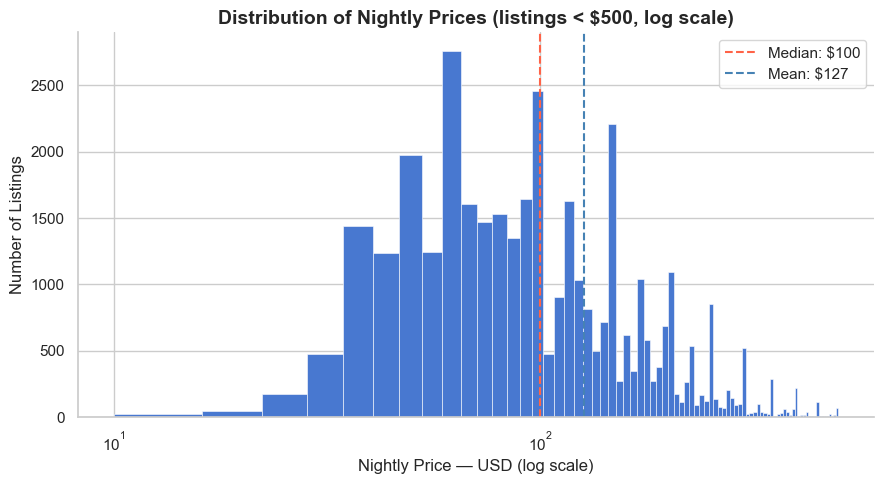

In [13]:
df_plot = df[df['price'] < 500].copy()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df_plot['price'],
    bins=80,
    color=sns.color_palette('muted')[0],
    edgecolor='white',
    linewidth=0.4,
    log=False,
)

ax.set_xscale('log')
ax.set_title('Distribution of Nightly Prices (listings < $500, log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Nightly Price — USD (log scale)', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)

# Mark median and mean
median_price = df_plot['price'].median()
mean_price = df_plot['price'].mean()
ax.axvline(median_price, color='tomato', linestyle='--', linewidth=1.5, label=f'Median: ${median_price:.0f}')
ax.axvline(mean_price, color='steelblue', linestyle='--', linewidth=1.5, label=f'Mean: ${mean_price:.0f}')
ax.legend(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()


### Plot 3 — Correlation Heatmap of Numeric Features

**What it shows:** The correlation matrix reveals that `calculated_host_listings_count` has a modest positive correlation with `price` (hosts with many listings tend to command slightly higher prices, possibly due to professional management). `availability_365` is weakly positively correlated with `price`, suggesting that expensive listings are not necessarily more frequently booked. Notably, `number_of_reviews` and `reviews_per_month` are strongly correlated with each other (as expected), and both have a slight negative correlation with price — lower-priced listings attract more reviews, consistent with higher turnover.


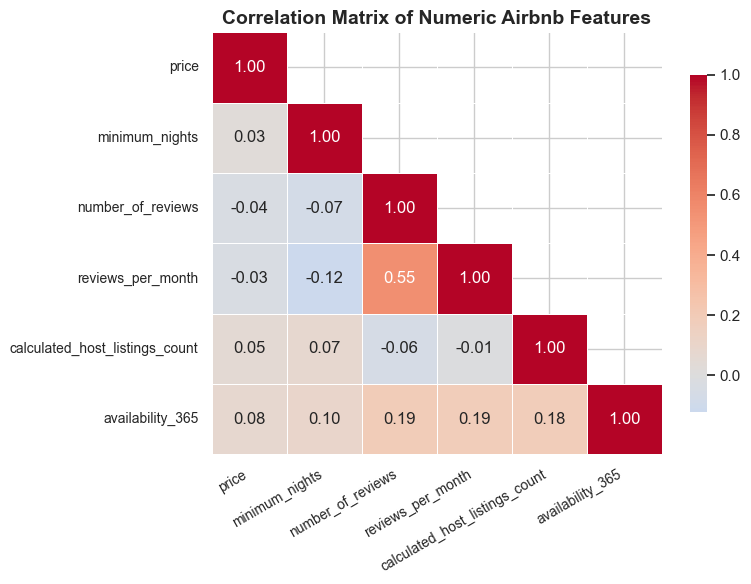

In [14]:
numeric_cols = [
    'price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # show lower triangle + diagonal

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8},
)

ax.set_title('Correlation Matrix of Numeric Airbnb Features', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()
